# Test for Tensorflow library installation

In [ ]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



In [66]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


## Import Dataset that contains sensor data from accelerometer and gyroscope

Import the loged data by ESP32 board from generated file

Make a look at the data and create a new column with a unique sample ID (Composed of SampleType and NumSample)

Graphically represent the data

Group the data by SampleId and create a dataframe with all the sensor data for each sample

In [67]:
#Open a csv file and read its contents

data = pd.read_csv('Lab2DataSet.txt', sep='\t')
print(data.head())

   SampleType  NumSample  numItem  accelX  accelY  accelZ  gyroX  gyroY  gyroZ
0           0          0        0   -0.00   -0.05    -1.0  -0.03   1.15   0.17
1           0          0        1    0.00   -0.09    -1.0  -0.22   0.03   0.54
2           0          0        2    0.01   -0.11    -1.0   0.16  -0.97  -0.21
3           0          0        3    0.00   -0.08    -1.0  -0.15  -0.91   0.11
4           0          0        4   -0.00   -0.19    -1.0   0.35  -5.97   0.36


In [68]:
# Create a new column composed of SampleType and NumSample "SampleId"
#format: SampleId_<SampleType>_<NumSample> where Numsample is a 2 digit number with leading zeros if needed
data['SampleId'] = 'SampleId_'+ data['SampleType'].astype(str) + '_' + data['NumSample'].astype(str).str.zfill(2)



print(data.head())

   SampleType  NumSample  numItem  accelX  accelY  accelZ  gyroX  gyroY  \
0           0          0        0   -0.00   -0.05    -1.0  -0.03   1.15   
1           0          0        1    0.00   -0.09    -1.0  -0.22   0.03   
2           0          0        2    0.01   -0.11    -1.0   0.16  -0.97   
3           0          0        3    0.00   -0.08    -1.0  -0.15  -0.91   
4           0          0        4   -0.00   -0.19    -1.0   0.35  -5.97   

   gyroZ       SampleId  
0   0.17  SampleId_0_00  
1   0.54  SampleId_0_00  
2  -0.21  SampleId_0_00  
3   0.11  SampleId_0_00  
4   0.36  SampleId_0_00  


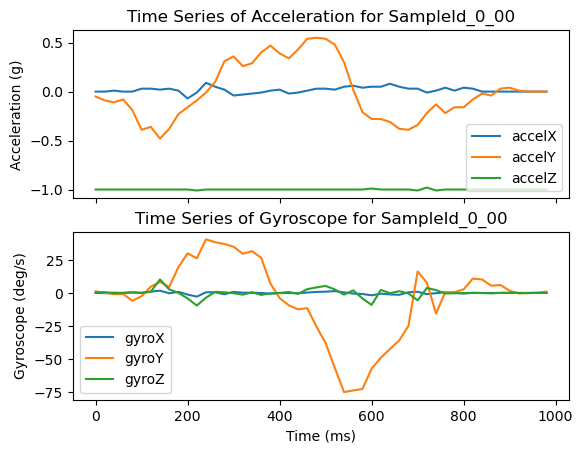

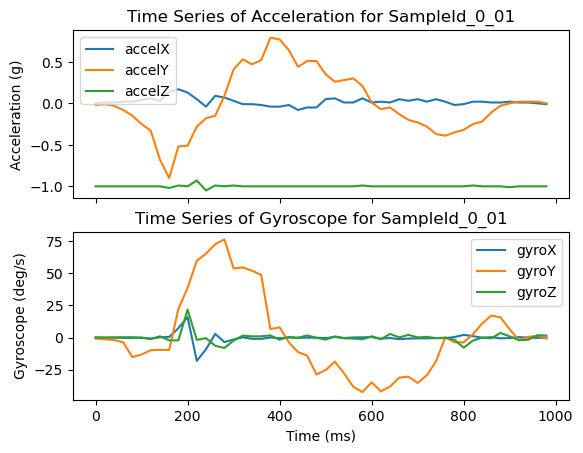

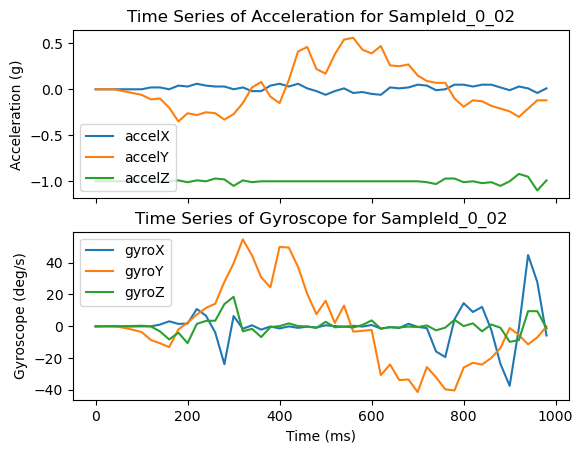

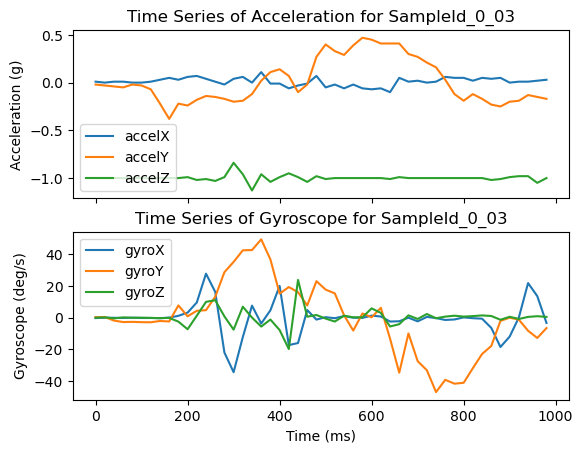

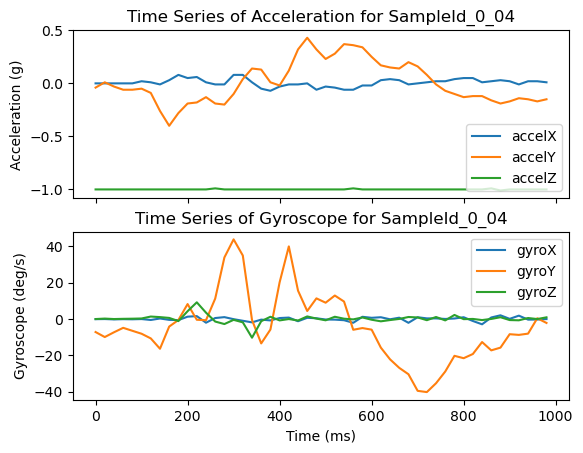

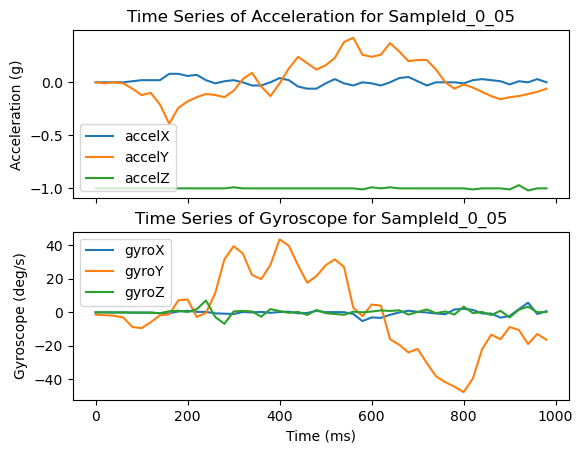

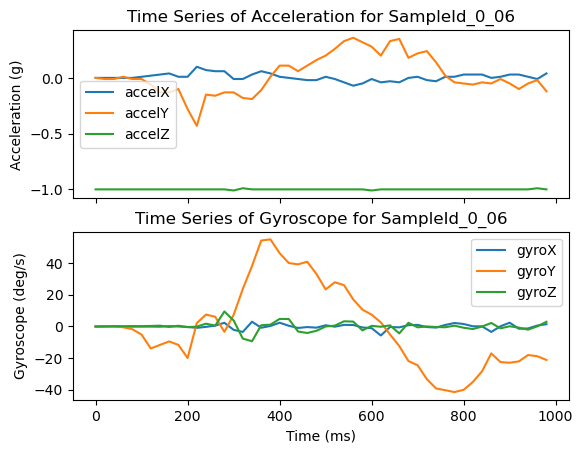

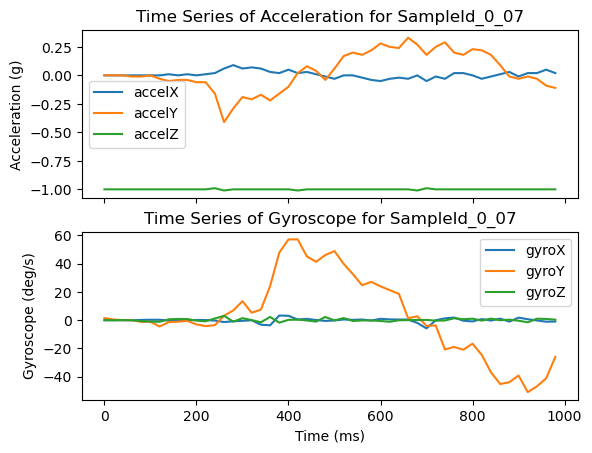

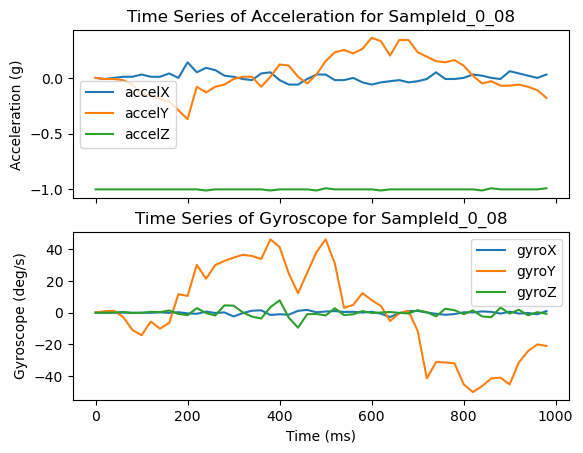

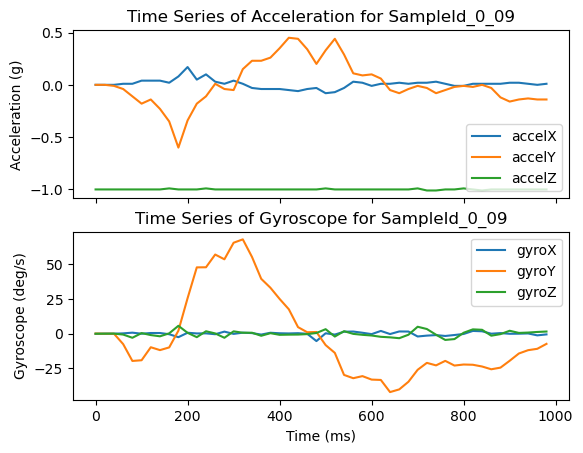

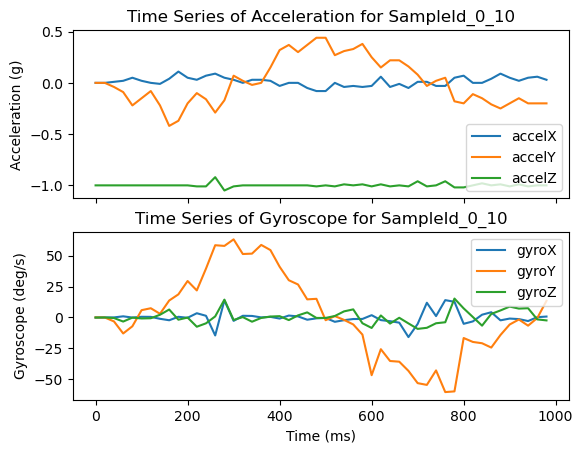

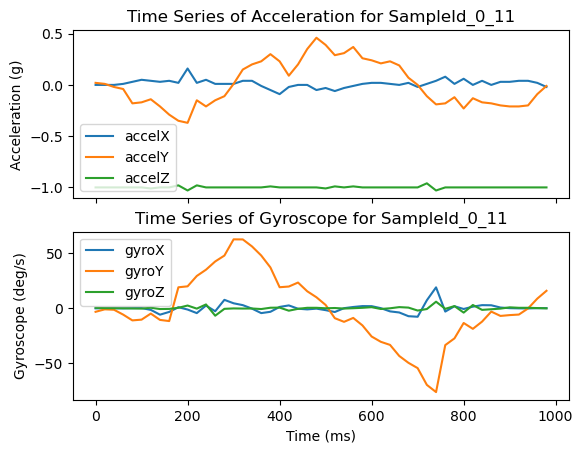

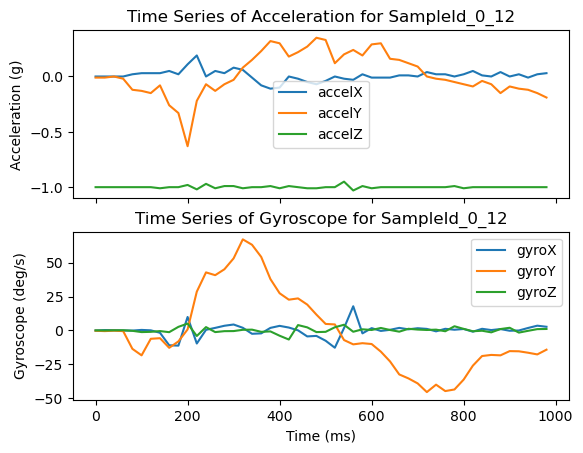

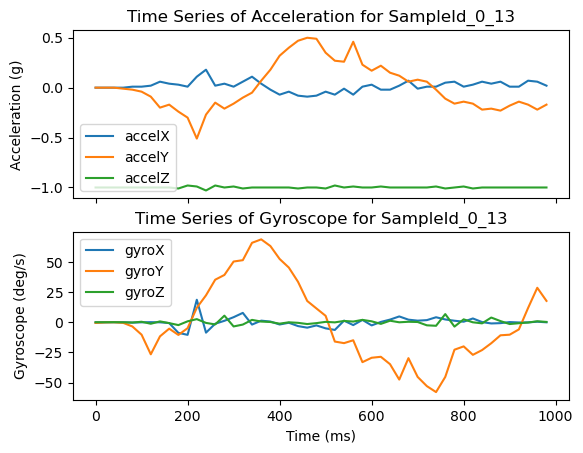

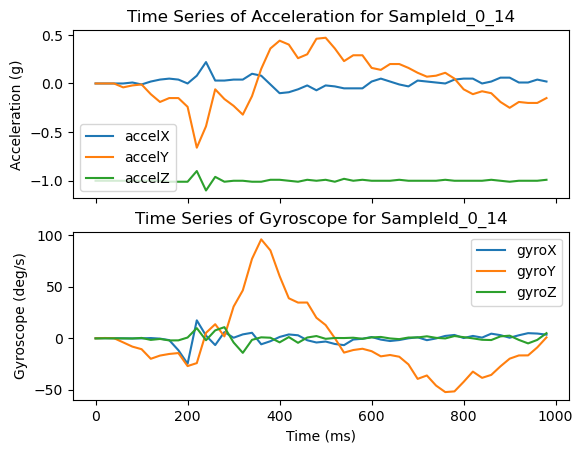

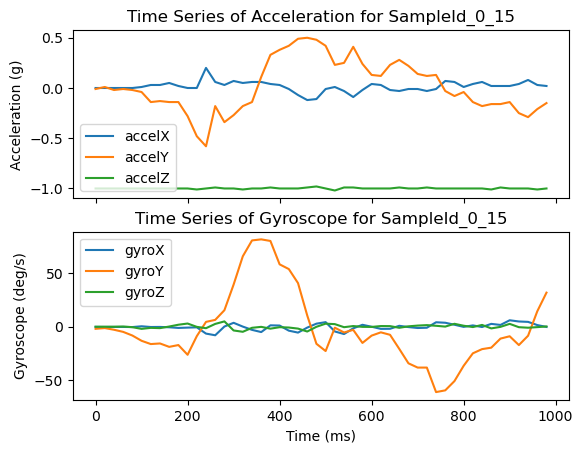

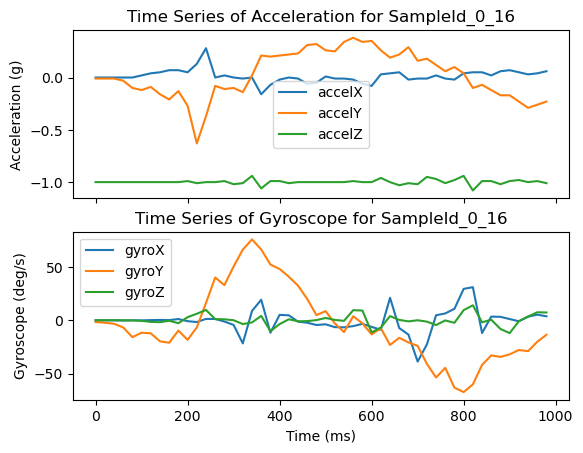

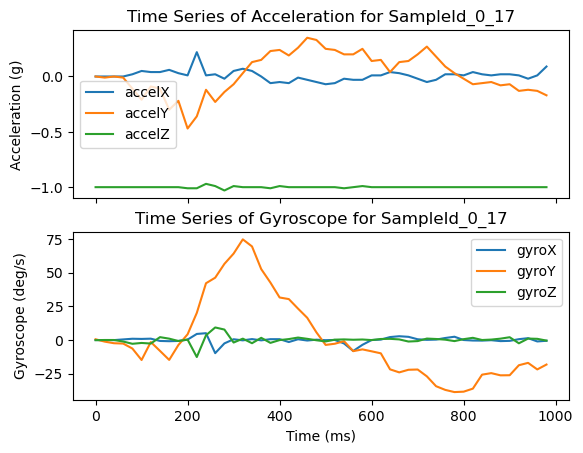

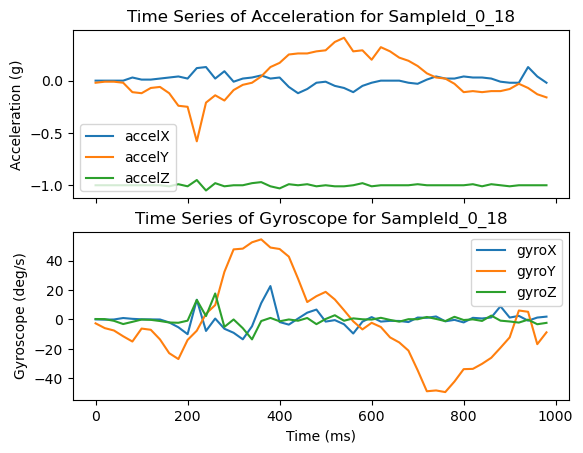

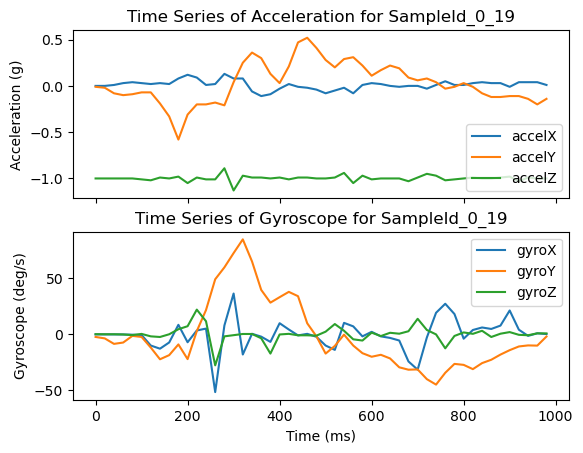

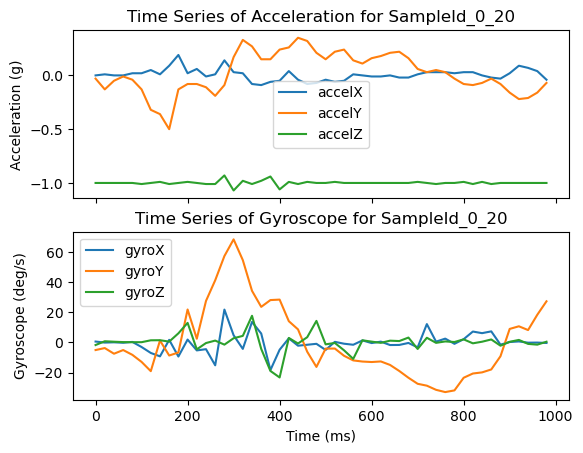

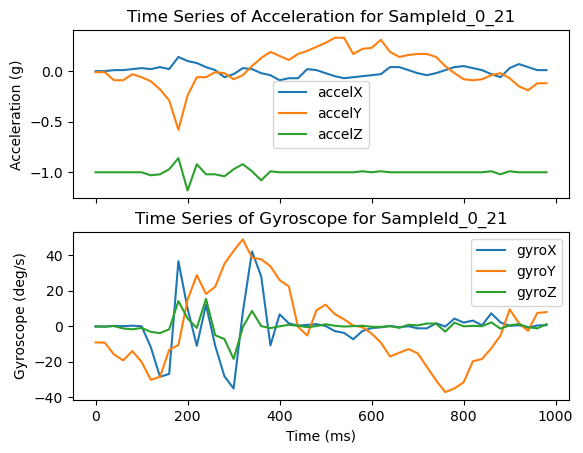

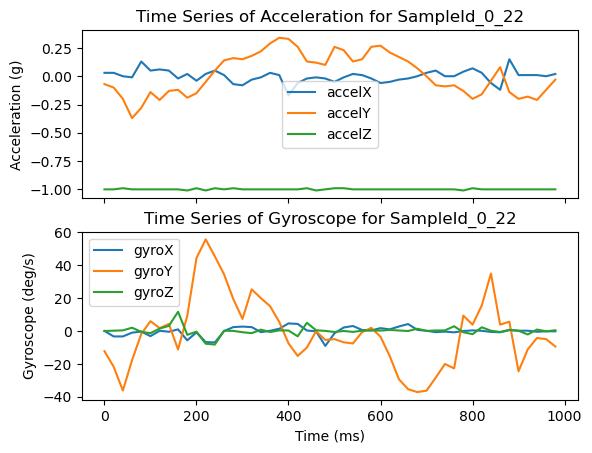

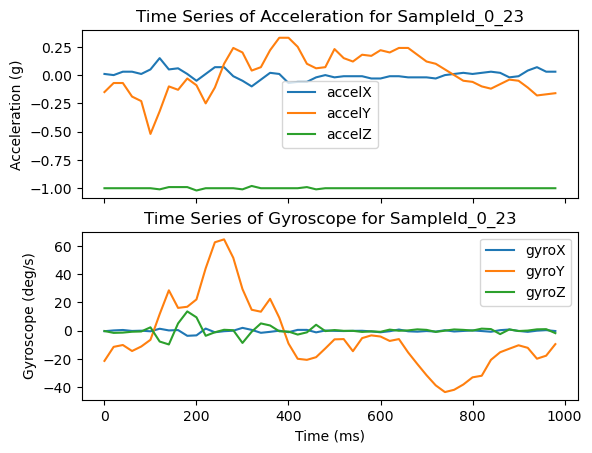

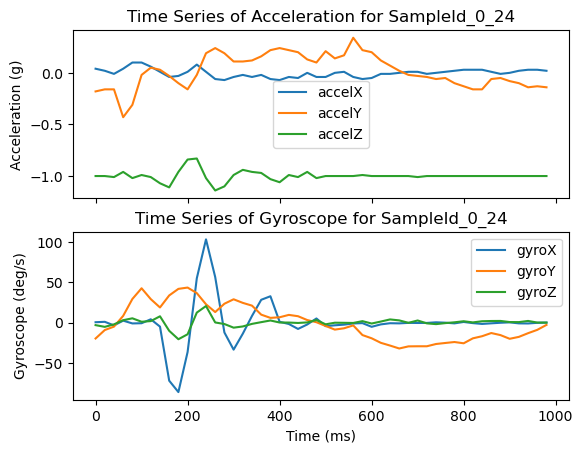

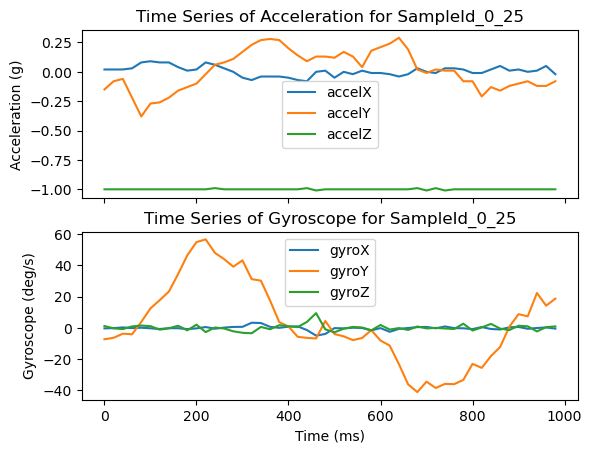

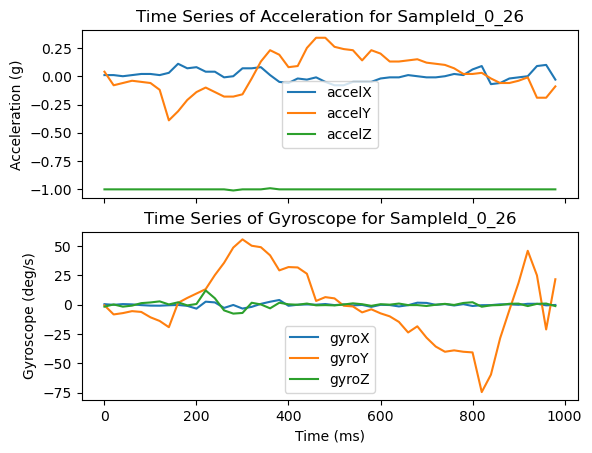

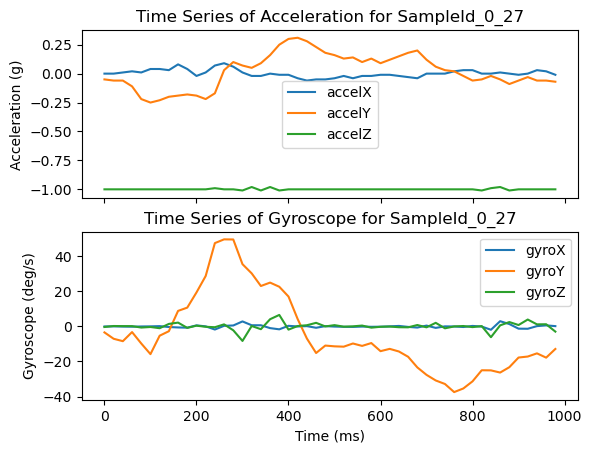

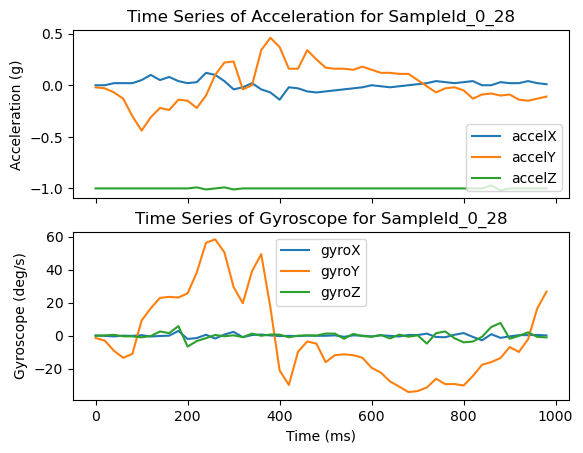

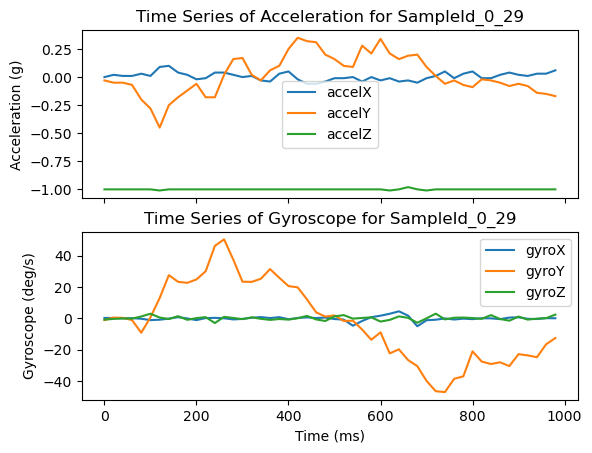

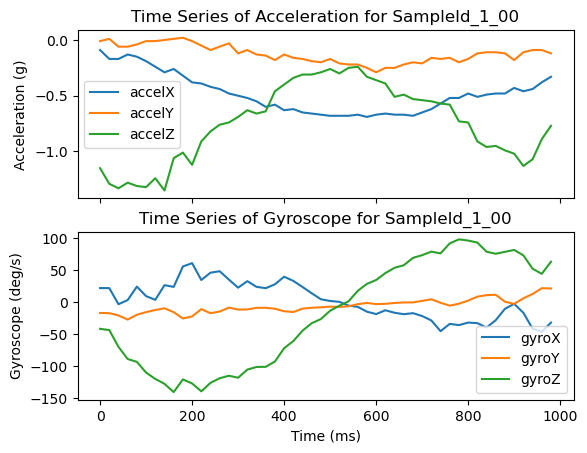

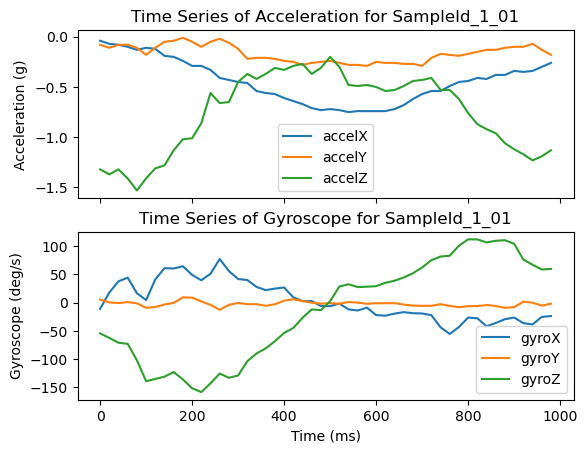

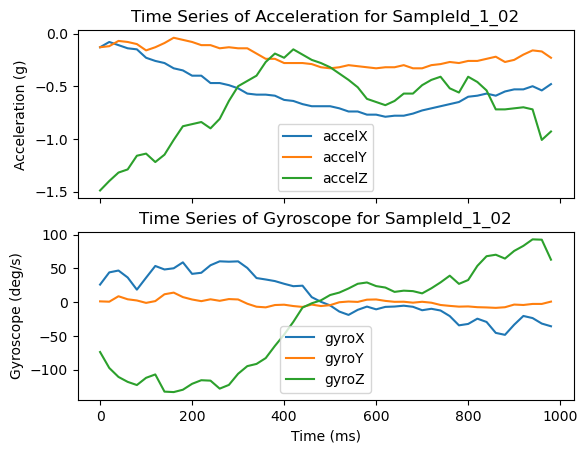

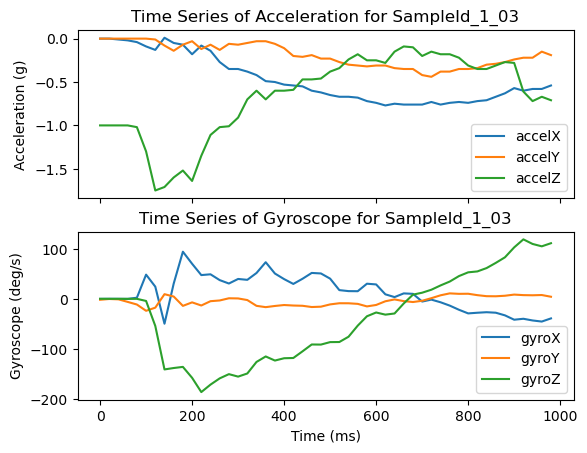

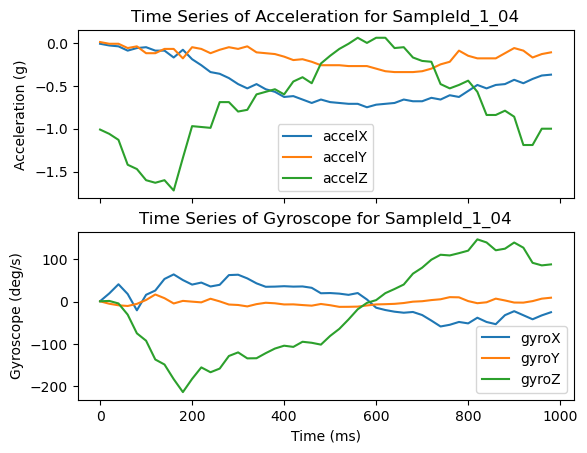

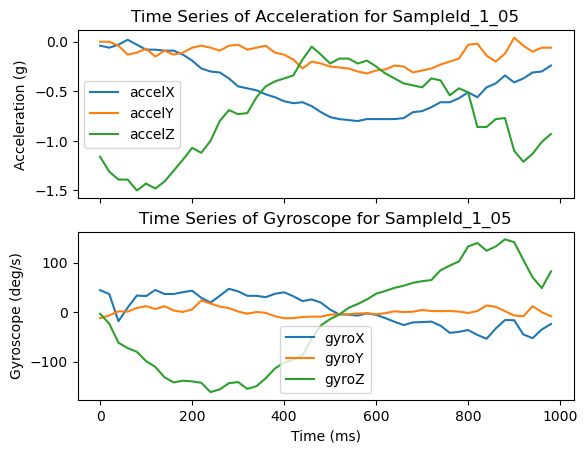

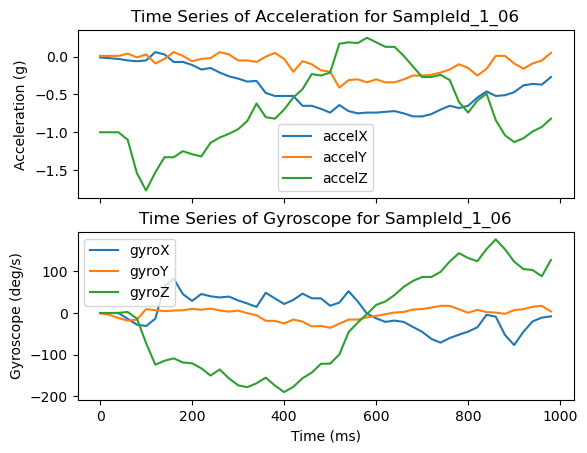

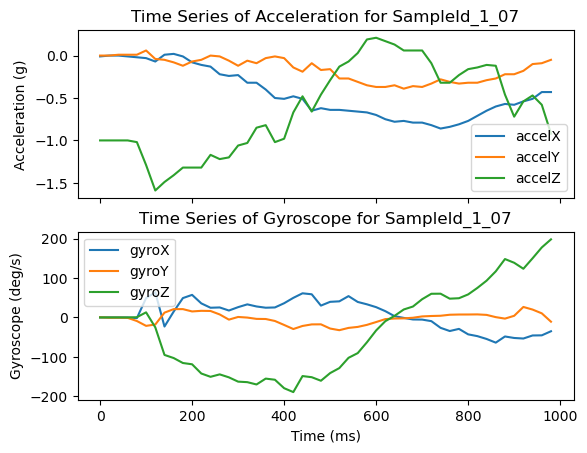

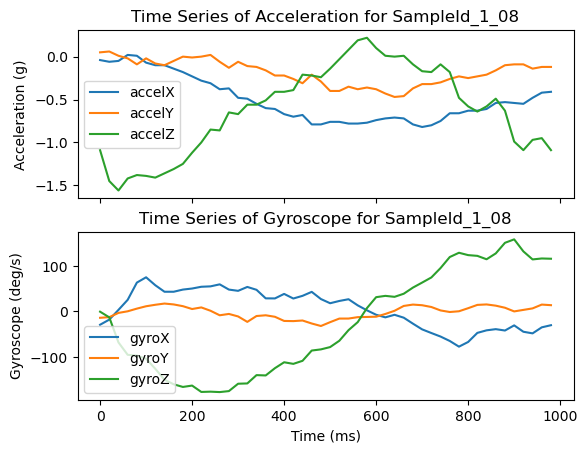

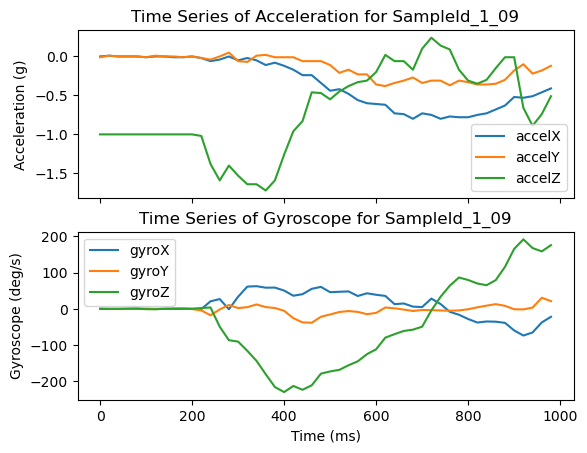

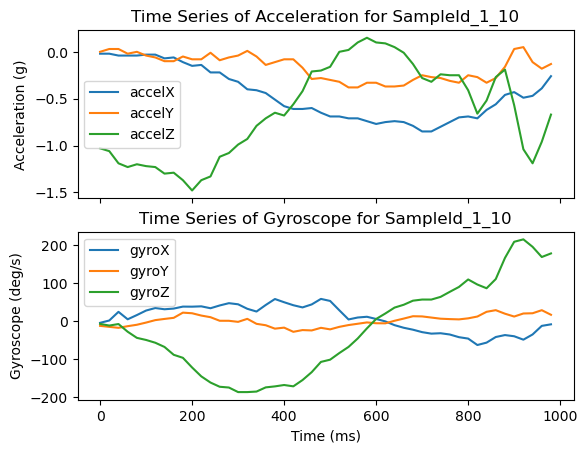

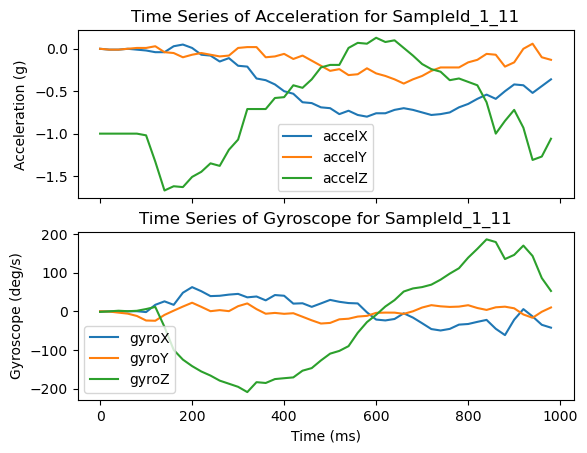

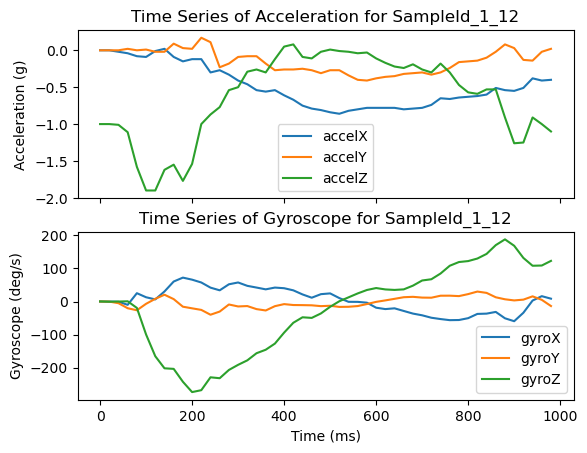

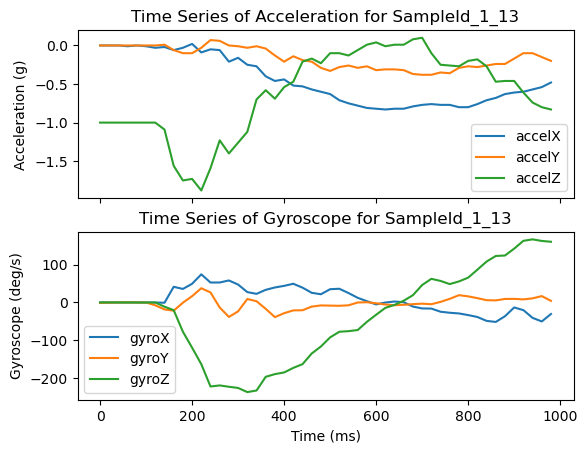

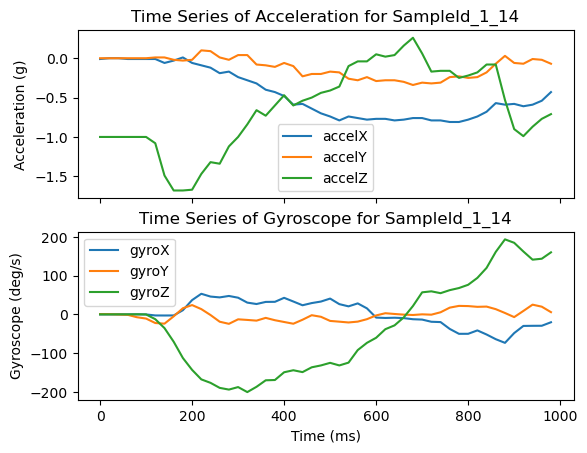

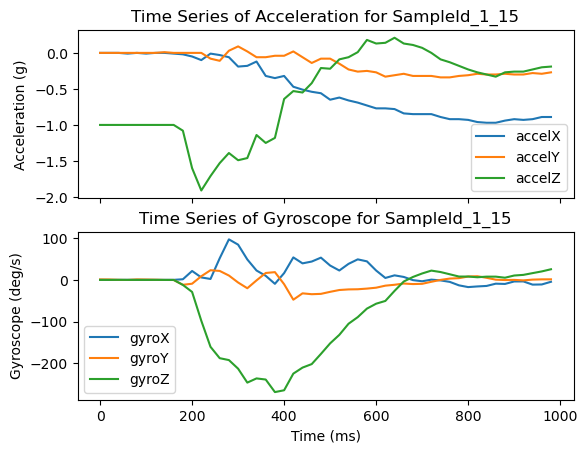

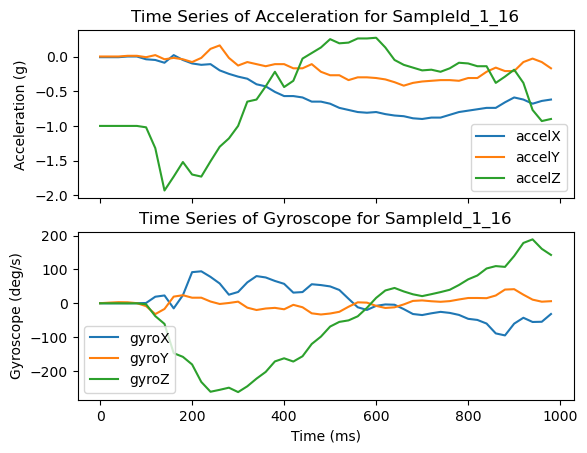

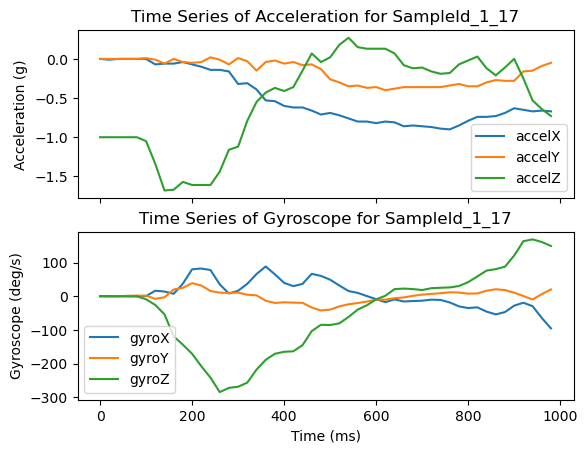

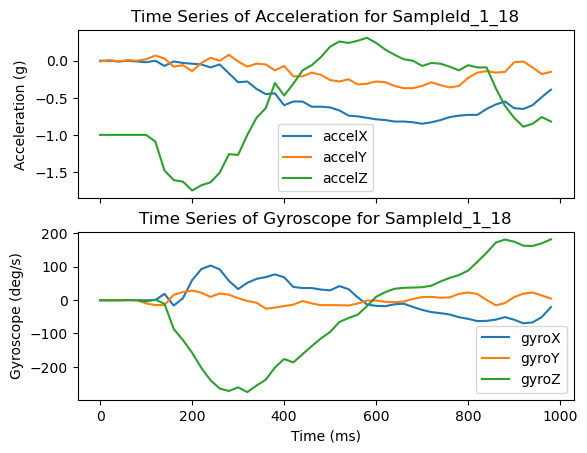

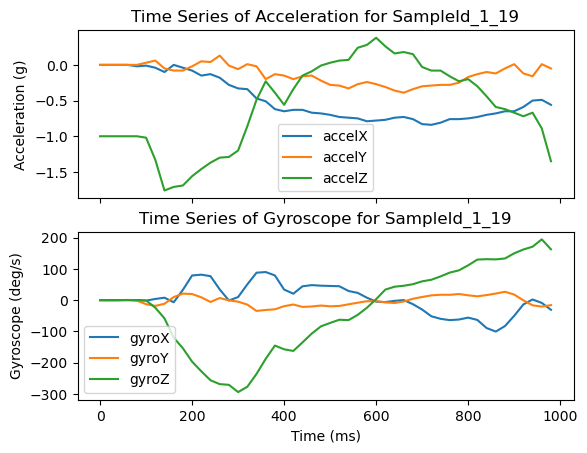

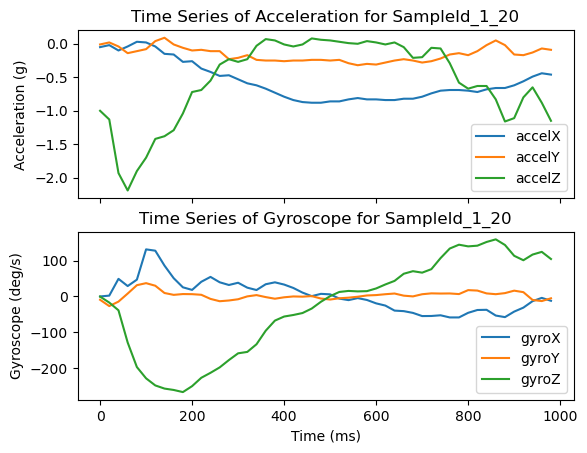

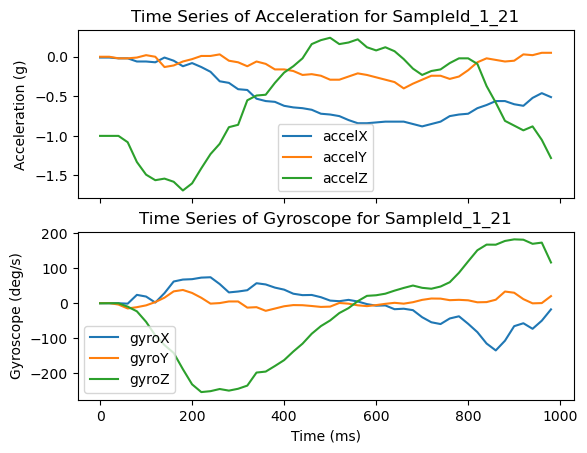

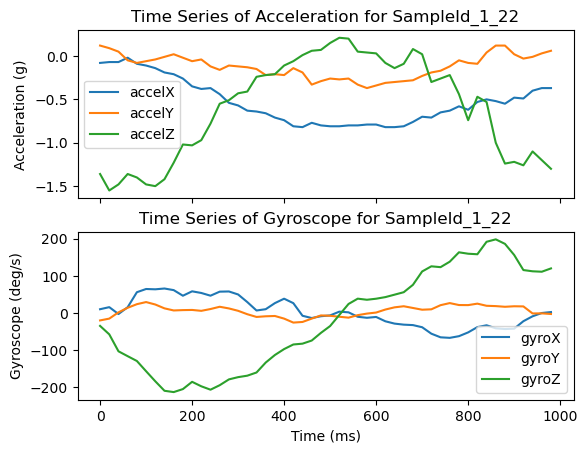

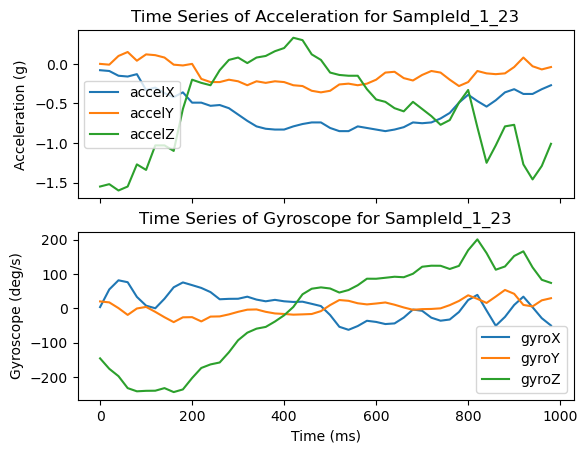

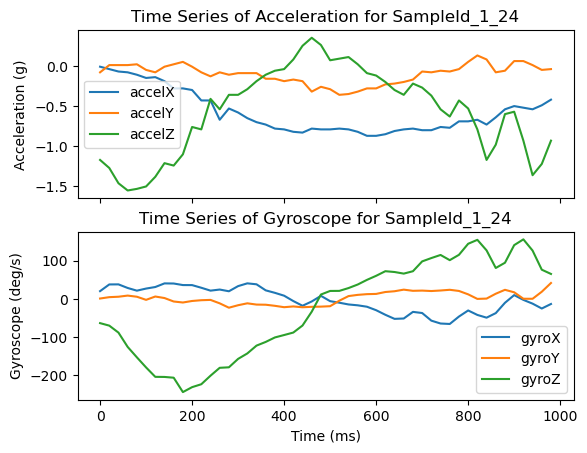

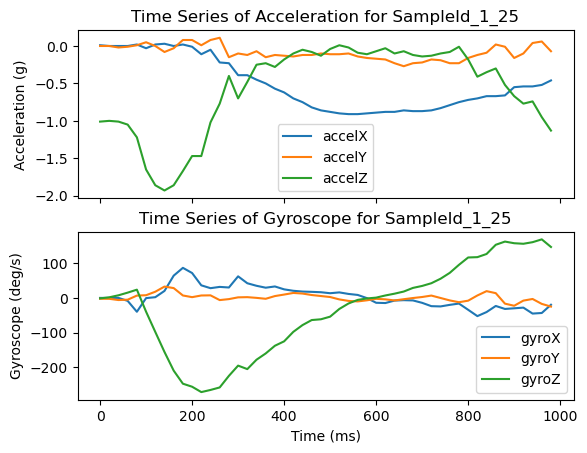

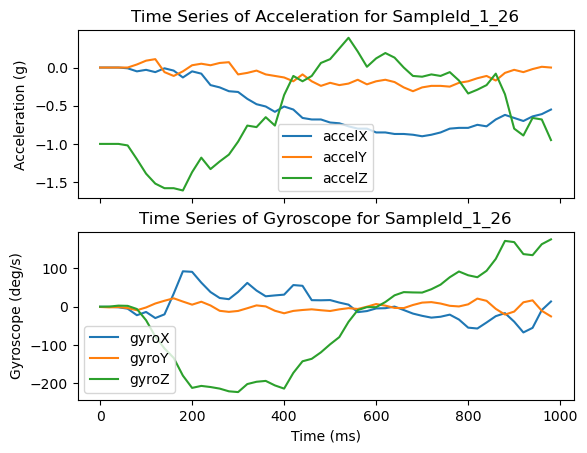

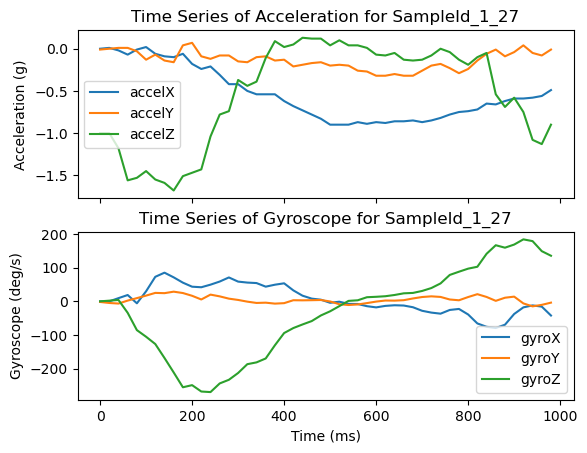

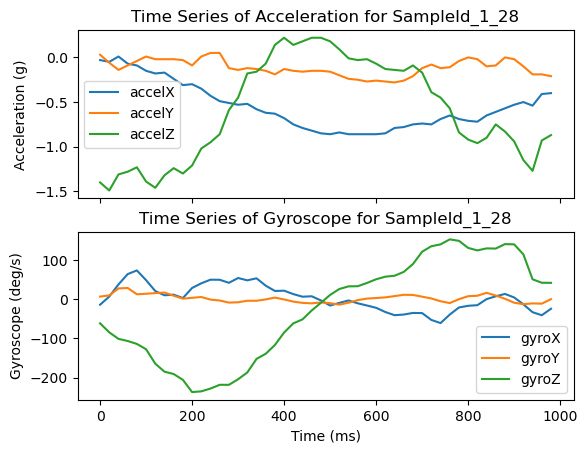

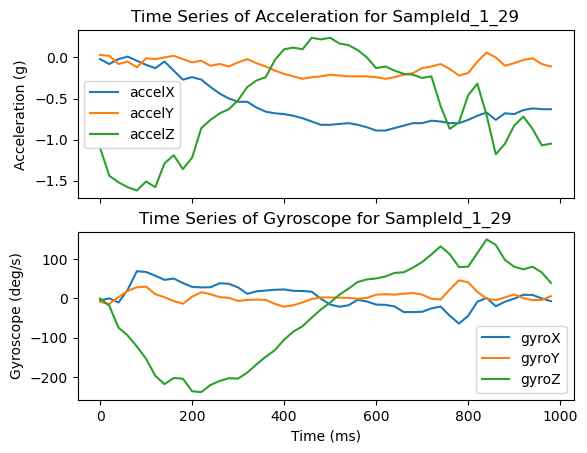

In [69]:
# Plot the time series accelX,accelY,accelZ for each SampleId="SampleId_0_00"



def PlotAccel(sample_data):
    plt.plot(sample_data['numItem']*20, sample_data['accelX'], label='accelX')
    plt.plot(sample_data['numItem']*20, sample_data['accelY'], label='accelY')
    plt.plot(sample_data['numItem']*20, sample_data['accelZ'], label='accelZ')
    plt.xlabel('Time (ms)')
    plt.legend()
    plt.title(f'Time Series of accelX for {sample_id}')
    plt.show()
def PlotGyro(sample_data):
    #plt.plot(sample_data['numItem']*20, sample_data['gyroX'], label='gyroX')
    #plt.plot(sample_data['numItem']*20, sample_data['gyroY'], label='gyroY')
    plt.plot(sample_data['numItem']*20, sample_data['gyroZ'], label='gyroZ')
    plt.xlabel('Time (ms)')
    plt.legend()
    plt.title(f'Time Series of gyroX for {sample_id}')
    plt.show()

def PlotAccelGyro(sample_data):
    #plot accel and gyro in 2 subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
    ax1.set_ylabel('Acceleration (g)')
    ax1.plot(sample_data['numItem']*20, sample_data['accelX'], label='accelX')
    ax1.plot(sample_data['numItem']*20, sample_data['accelY'], label='accelY')
    ax1.plot(sample_data['numItem']*20, sample_data['accelZ'], label='accelZ')
    ax1.legend()
    ax1.set_title(f'Time Series of Acceleration for {sample_id}')
    ax2.set_xlabel('Time (ms)')
    ax2.set_ylabel('Gyroscope (deg/s)')
    ax2.plot(sample_data['numItem']*20, sample_data['gyroX'], label='gyroX')
    ax2.plot(sample_data['numItem']*20, sample_data['gyroY'], label='gyroY')
    ax2.plot(sample_data['numItem']*20, sample_data['gyroZ'], label='gyroZ')
    ax2.legend()
    ax2.set_title(f'Time Series of Gyroscope for {sample_id}')
    plt.show()


for sample_id in data['SampleId'].unique():
    sample_data = data[data['SampleId'] == sample_id]
    PlotAccelGyro(sample_data)

Prepare a dataset for training a neural network with Tensorflow

In [70]:
# Create a new dataset that contains the following columns: SampleId, Item0_accelX, Item0_accelY, Item0_accelZ, Item0_gyroX, Item0_gyroY, Item0_gyroZ, ... Item49_accelX, Item49_accelY, Item49_accelZ, Item49_gyroX, Item49_gyroY, Item49_gyroZ
columns = ['SampleId']

for i in range(50):
    columns += [f'Item{i}_accelX', f'Item{i}_accelY', f'Item{i}_accelZ', f'Item{i}_gyroX', f'Item{i}_gyroY', f'Item{i}_gyroZ']
columns += ['SampleType']
new_data = pd.DataFrame(columns=columns)


for sample_id, group in data.groupby('SampleId'):
    row = {'SampleId': sample_id}
    row['SampleType'] = group['SampleType'].iloc[0] 
    for _, item in group.iterrows():
        numItem = item['numItem']  # Ensure square brackets are used to access the column value
        row[f'Item{numItem}_accelX'] = item['accelX']
        row[f'Item{numItem}_accelY'] = item['accelY']
        row[f'Item{numItem}_accelZ'] = item['accelZ']
        row[f'Item{numItem}_gyroX'] = item['gyroX']
        row[f'Item{numItem}_gyroY'] = item['gyroY']
        row[f'Item{numItem}_gyroZ'] = item['gyroZ']
    new_data = pd.concat([new_data, pd.DataFrame([row])], ignore_index=True)
    #new_data = new_data.append(row, ignore_index=True)
print(new_data.shape)

print(new_data.head())

print(new_data.tail())

C:\Users\rrena\AppData\Local\Temp\ipykernel_20508\4211159721.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  new_data = pd.concat([new_data, pd.DataFrame([row])], ignore_index=True)


(60, 302)
        SampleId  Item0_accelX  Item0_accelY  Item0_accelZ  Item0_gyroX  \
0  SampleId_0_00         -0.00         -0.05          -1.0        -0.03   
1  SampleId_0_01         -0.00         -0.02          -1.0        -0.09   
2  SampleId_0_02         -0.00         -0.00          -1.0        -0.09   
3  SampleId_0_03          0.01         -0.02          -1.0        -0.22   
4  SampleId_0_04          0.00         -0.04          -1.0        -0.15   

   Item0_gyroY  Item0_gyroZ  Item1_accelX  Item1_accelY  Item1_accelZ  ...  \
0         1.15         0.17          0.00         -0.09          -1.0  ...   
1        -0.85         0.04          0.01         -0.01          -1.0  ...   
2        -0.35        -0.08         -0.00         -0.00          -1.0  ...   
3         0.40         0.04          0.00         -0.03          -1.0  ...   
4        -7.22        -0.08         -0.00          0.01          -1.0  ...   

   Item48_gyroX  Item48_gyroY  Item48_gyroZ  Item49_accelX  Item49_acc

In [74]:
# extract features(SampleType) and the rest of the columns as feautures
X = new_data.drop(columns=['SampleId', 'SampleType'])
y = new_data['SampleType']

print(X.shape)
print(y.shape)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(60, 300)
(60,)
(48, 300) (12, 300) (48,) (12,)


# Create a model and train it with the dataset

In [83]:
# Create a nnural network model with tensorflow
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(len(y.unique()), activation='softmax')  # Output layer with number of classes
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
# Ensure labels are numeric
y_train = y_train.astype('int64')
y_test = y_test.astype('int64')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=8, validation_split=0.2)
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')


Epoch 1/50


c:\Users\rrena\miniconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2371 - loss: 18.2271 - val_accuracy: 0.8000 - val_loss: 1.8896
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6395 - loss: 1.5297 - val_accuracy: 0.9000 - val_loss: 0.6240
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9165 - loss: 0.0991 - val_accuracy: 0.9000 - val_loss: 0.0718
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0122 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 1.9159e-04
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 5.3399e-05
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 3.0503e-05
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 3.2874e-04 - val_accuracy: 1.0000 - val_loss: 2.3387e-